# Stress Inference — Complete Notebook (Training + All Experiments)
**Cosinor-Enhanced Multi-Level Stress Inference from Wearable RR Intervals**

Runs top-to-bottom in one session and produces every result for the dissertation.

**Contents**
1. Imports & config
2. Helper functions
3. WESAD preprocessing (ECG->RR + temperature)
4. Cosinor fitting (HRV + temperature)
5. Feature matrices (XGBoost) + sequence windows (deep learning)
6. Models & loss
7. Experiment 1 - XGBoost ablation: HRV-only vs +Cosinor
8-9. Experiments 2 & 3 - CNN-BiLSTM-Attention v2 + Ensemble (LOSO-CV, cached)
10. Train final deployable models (all data)
11. Experiment 4 - SHAP feature importance
12. Experiment 5 - Confusion matrix (ensemble)
13. Experiment 6 - Per-class summary + full comparison table
14. Save models, results, download links

Fixes: temperature alignment, np.trapz->scipy trapezoid, distinct variable names,
model saving with download links.


## 1. Imports & Configuration

In [1]:
!pip install neurokit2 shap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 13.4 MB/s eta 0:00:00


In [2]:
import os, json, pickle, warnings
import numpy as np, pandas as pd
from scipy.signal import welch
from scipy.optimize import curve_fit
try:
    from scipy.integrate import trapezoid as TRAPZ
except ImportError:
    from scipy.integrate import trapz as TRAPZ
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (f1_score, cohen_kappa_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow.keras import layers, callbacks, Model
from tensorflow.keras.losses import Loss
import neurokit2 as nk
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
print("TF:", tf.__version__, "| GPU:", len(tf.config.list_physical_devices('GPU'))>0)

DATA_PATH   = '/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD'
SAVE_PATH   = '/kaggle/working/processed'
MODELS_PATH = f'{SAVE_PATH}/models'
os.makedirs(MODELS_PATH, exist_ok=True)

SUBJECT_IDS = [2,3,4,5,6,7,8,9,10,11,13,14,15,16,17]
CLASS_NAMES = ['relaxed','mild','moderate','high']
W_XGB, W_CNN = 0.45, 0.55

FEATURE_NAMES = ['mean_rr','sdnn','rmssd','pnn50','cv_rr','vlf','lf','hf',
                 'lf_hf','lf_nu','sd1','sd2','sd_ratio']
RESIDUAL_NAMES = ['res_mean','res_std','res_max','res_trend','res_energy']
CIRC_NAMES = ['sin_24h','cos_24h','sin_90m','cos_90m','cortisol']
XGB_FEATURE_NAMES = FEATURE_NAMES + RESIDUAL_NAMES + ['mesor','amplitude'] + CIRC_NAMES
print("Config loaded. XGB features:", len(XGB_FEATURE_NAMES))

TF: 2.20.0 | GPU: True
Config loaded. XGB features: 25


## 2. Helper Functions

In [3]:
def load_subject(subject_id):
    path=f"{DATA_PATH}/S{subject_id}/S{subject_id}.pkl"
    with open(path,'rb') as f: data=pickle.load(f,encoding='latin1')
    chest=data['signal']['chest']
    wrist_temp=data['signal']['wrist']['TEMP'].flatten()
    labels=data['label'].flatten()
    return chest, wrist_temp, labels

def extract_rr_from_ecg(ecg_signal, fs=700):
    ecg=nk.ecg_clean(ecg_signal.flatten(), sampling_rate=fs)
    _, info=nk.ecg_peaks(ecg, sampling_rate=fs)
    rp=info['ECG_R_Peaks']
    rr=np.diff(rp)*(1000.0/fs); ts=(rp[:-1]+rp[1:])/2.0/fs
    return rr, ts, rp

def clean_rr(rr_ms, timestamps):
    rr=rr_ms.copy().astype(float); rr[(rr<=300)|(rr>=2000)]=np.nan
    for i in range(1,len(rr)):
        if not np.isnan(rr[i-1]) and not np.isnan(rr[i]):
            if abs(rr[i]-rr[i-1])/rr[i-1]>0.20: rr[i]=np.nan
    m=np.isnan(rr)
    if m.any(): rr[m]=np.interp(np.where(m)[0],np.where(~m)[0],rr[~m])
    return rr, timestamps.copy()

def align_temp_to_rr(wrist_temp, rpeaks, fs_ecg=700, fs_temp=4.0):
    rt=rpeaks/fs_ecg; tt=np.arange(len(wrist_temp))/fs_temp
    tap=np.interp(rt,tt,wrist_temp); return (tap[:-1]+tap[1:])/2.0

def assign_labels_to_rr(labels, rpeaks):
    out=[]
    for i in range(len(rpeaks)-1):
        seg=labels[rpeaks[i]:rpeaks[i+1]]; v=seg[seg>0]
        out.append(0 if len(v)==0 else np.bincount(v).argmax())
    return np.array(out)

def extract_hrv_features(rr_window, fs_resample=4.0):
    rr,diff=np.array(rr_window),np.diff(rr_window)
    mean_rr=np.mean(rr); sdnn=np.std(rr)
    rmssd=np.sqrt(np.mean(diff**2)); pnn50=np.sum(np.abs(diff)>50)/len(diff)*100
    cv_rr=sdnn/mean_rr
    times=np.cumsum(rr)/1000.0
    rr_u=np.interp(np.arange(0,times[-1],1/fs_resample),times,rr)
    freqs,psd=welch(rr_u,fs=fs_resample,nperseg=min(256,len(rr_u)))
    vlf=TRAPZ(psd[(freqs>=0.003)&(freqs<0.04)]); lf=TRAPZ(psd[(freqs>=0.04)&(freqs<0.15)])
    hf=TRAPZ(psd[(freqs>=0.15)&(freqs<0.40)])
    lf_hf=lf/(hf+1e-8); lf_nu=lf/(lf+hf+1e-8)
    sd1=np.sqrt(0.5)*np.std(diff); sd2=np.sqrt(max(2*sdnn**2-0.5*np.var(diff),0))
    sd_ratio=sd1/(sd2+1e-8)
    return np.array([mean_rr,sdnn,rmssd,pnn50,cv_rr,vlf,lf,hf,lf_hf,lf_nu,sd1,sd2,sd_ratio])

def extract_residual_features(rw):
    r=np.array(rw)
    return np.array([np.mean(r),np.std(r),np.max(np.abs(r)),
                     np.polyfit(np.arange(len(r)),r,1)[0],np.sum(r**2)/len(r)])

def get_circadian_features(elapsed_sec, session_start_hour=0.0):
    # elapsed_sec = seconds since the recording started (WESAD gives elapsed time, NOT wall clock).
    # session_start_hour = real clock hour (0-24) when the recording began.
    # Without a real start hour the sin/cos(24h) and cortisol terms are meaningless,
    # so they must be supplied from the dataset metadata (see SESSION_START_HOUR).
    hour = (session_start_hour + elapsed_sec/3600.0) % 24.0
    t = hour*3600.0
    cortisol=(0.6*np.exp(-0.5*((hour-8)/1.5)**2)+0.3*np.exp(-0.5*((hour-15)/1.5)**2))
    return np.array([np.sin(2*np.pi*t/86400),np.cos(2*np.pi*t/86400),
                     np.sin(2*np.pi*t/5400),np.cos(2*np.pi*t/5400),cortisol])

def cosinor_model(t_hours,mesor,amplitude,acrophase):
    return mesor+amplitude*np.cos((2*np.pi/24.0)*t_hours+acrophase)

# WESAD stores ELAPSED time only (no wall-clock). We cannot know the true start hour,
# so circadian features on WESAD are placeholders and must NOT be reported as validated.
# For a longitudinal dataset (TILES / your IoT logs) fill real start hours here.
SESSION_START_HOUR = {f'S{sid}': 0.0 for sid in SUBJECT_IDS}
WESAD_HAS_WALLCLOCK = False  # set True only when real timestamps are available


def fit_cosinor(signal, timestamps, p0, session_start_hour=0.0):
    # timestamps = elapsed seconds since recording start.
    # Convert to REAL clock hours using the session start hour.
    t_hours=(session_start_hour + timestamps/3600.0)  # NOT %24, keep monotonic for the fit
    span_h=float(t_hours.max()-t_hours.min())
    try:
        popt,_=curve_fit(cosinor_model,t_hours,signal,p0=p0,maxfev=10000)
        baseline=cosinor_model(t_hours,*popt); mesor,amp=popt[0],popt[1]
        r2=1-np.sum((signal-baseline)**2)/np.sum((signal-np.mean(signal))**2)
    except RuntimeError:
        baseline=np.full_like(signal,np.mean(signal)); mesor,amp,r2=float(np.mean(signal)),0.0,0.0
    # A 24h cosine cannot be identified from a recording much shorter than 24h.
    identifiable = span_h >= 12.0
    return baseline, signal-baseline, mesor, amp, r2, span_h, identifiable

def rolling_rmssd(rr):
    out=np.zeros(len(rr))
    for i in range(len(rr)):
        w=rr[max(0,i-10):i+10]; d=np.diff(w)
        out[i]=np.sqrt(np.mean(d**2)) if len(d)>1 else 0
    return out
def rolling_sdnn(rr):
    out=np.zeros(len(rr))
    for i in range(len(rr)):
        w=rr[max(0,i-10):i+10]; out[i]=np.std(w) if len(w)>1 else 0
    return out

def create_windows(rr_ms, labels, window_size=60, step=10):
    Xw,yw=[],[]
    for s in range(0,len(rr_ms)-window_size,step):
        Xw.append(rr_ms[s:s+window_size]); yw.append(np.bincount(labels[s:s+window_size]).argmax())
    return np.array(Xw),np.array(yw)
print("Helpers defined.")

Helpers defined.


## 3. WESAD Preprocessing (ECG -> RR + Temperature)

In [4]:
wesad={}
print("Processing WESAD...\n")
for sid in SUBJECT_IDS:
    print(f"S{sid}...",end=' ')
    try:
        chest, wrist_temp, labels = load_subject(sid)
        ecg=chest['ECG'].flatten()
        rr_ms, ts, rpeaks = extract_rr_from_ecg(ecg, fs=700)
        temp_all = align_temp_to_rr(wrist_temp, rpeaks)
        rr_clean, ts_clean = clean_rr(rr_ms, ts)
        rr_labels = assign_labels_to_rr(labels, rpeaks)
        keep=rr_labels>0
        rr_k,temp_k,ts_k,lab_k=rr_clean[keep],temp_all[keep],ts_clean[keep],rr_labels[keep]
        new=np.zeros(len(lab_k),dtype=int); sidx=np.where(lab_k==2)[0]
        if len(sidx)>0:
            srr=rr_k[sidx]; loc=[]
            for i in range(len(srr)):
                w=srr[max(0,i-15):i+15]; dd=np.diff(w)
                loc.append(np.sqrt(np.mean(dd**2)) if len(dd)>0 else 50)
            loc=np.array(loc); p33,p66=np.percentile(loc,33),np.percentile(loc,66)
            for i,idx in enumerate(sidx):
                new[idx]=(1 if loc[i]>=p66 else 2 if loc[i]>=p33 else 3)
        wesad[f'S{sid}']={'rr_ms':rr_k,'temp':temp_k,'timestamps':ts_k,'labels':new}
        print(f"{len(rr_k)} beats {np.bincount(new,minlength=4)}")
    except Exception as e:
        print(f"FAILED: {e}")
print(f"\n{len(wesad)} subjects loaded.")

Processing WESAD...

S2... 3591 beats [2801  269  260  261]
S3... 3177 beats [2253  314  305  305]
S4... 3398 beats [2555  287  278  278]
S5... 3695 beats [2734  327  317  317]
S6... 3711 beats [2858  290  281  282]
S7... 3626 beats [2728  305  296  297]
S8... 3938 beats [2929  343  333  333]
S9... 4106 beats [3247  292  283  284]
S10... 4943 beats [3647  441  427  428]
S11... 4689 beats [3275  481  466  467]
S13... 4636 beats [3435  409  396  396]
S14... 4689 beats [3264  486  470  469]
S15... 4177 beats [3207  330  320  320]
S16... 4482 beats [3044  489  477  472]
S17... 4131 beats [2764  465  451  451]

15 subjects loaded.


## 4. Cosinor Fitting (HRV + Temperature)

In [5]:
wesad_cos={}
print(f"{'subj':6} {'HRV_R2':>7} {'Temp_R2':>7} {'span_h':>7} {'24h_fit?':>9}")
print('-'*45)
any_identifiable=False
for sid,d in wesad.items():
    ssh=SESSION_START_HOUR.get(sid,0.0)
    _, rr_res, mesor, amp, r2h, span_h, ident = fit_cosinor(
        d['rr_ms'], d['timestamps'], p0=[np.mean(d['rr_ms']),50.0,-1.5], session_start_hour=ssh)
    _, temp_res, _, _, r2t, _, _ = fit_cosinor(
        d['temp'], d['timestamps'], p0=[np.mean(d['temp']),1.0,-1.5], session_start_hour=ssh)
    wesad_cos[sid]={'residual':rr_res,'rr_res':rr_res,'temp_res':temp_res,
                    'mesor':mesor,'amplitude':amp,'span_h':span_h,'identifiable':ident}
    any_identifiable |= ident
    print(f"{sid:6} {r2h:7.3f} {r2t:7.3f} {span_h:7.2f} {'YES' if ident else 'no':>9}")

print('-'*45)
if not any_identifiable:
    print("\n[WARNING] No subject spans >=12h. A 24-hour Cosinor rhythm is NOT identifiable")
    print("          on this dataset. Here the 'Cosinor residual' is just a detrended/centered")
    print("          signal, NOT a validated circadian model. Report it that way, and validate")
    print("          the true 24h claim only on a longitudinal dataset (TILES / IoT logs).")
print("Cosinor fitted.")

subj    HRV_R2 Temp_R2  span_h  24h_fit?
---------------------------------------------
S2       0.195   0.720    1.55        no
S3       0.344   0.846    1.62        no
S4       0.222   0.964    1.61        no
S5       0.386   0.914    1.55        no
S6       0.131   0.213    1.74        no
S7       0.010   0.850    1.37        no
S8       0.165   0.935    1.43        no
S9       0.031   0.791    1.39        no
S10      0.029   0.961    1.45        no
S11      0.421   0.910    1.39        no
S13      0.115   0.636    1.46        no
S14      0.551   0.806    1.49        no
S15      0.178   0.510    1.38        no
S16      0.586   0.755    1.48        no
S17      0.327   0.887    1.54        no
---------------------------------------------

[WARNING] No subject spans >=12h. A 24-hour Cosinor rhythm is NOT identifiable
          on this dataset. Here the 'Cosinor residual' is just a detrended/centered
          signal, NOT a validated circadian model. Report it that way, and validate
    

## 5. Feature Matrices + Sequence Windows

In [6]:
def build_hrv_matrix(data, window_size=60, step=10):
    X,y,g=[],[],[]
    for sid,d in tqdm(data.items()):
        Xw,yw=create_windows(d['rr_ms'],d['labels'],window_size,step)
        for i,(win,lab) in enumerate(zip(Xw,yw)):
            try:
                bi=min(i*step+window_size//2,len(d['timestamps'])-1)
                X.append(np.concatenate([extract_hrv_features(win),
                                         get_circadian_features(d['timestamps'][bi], SESSION_START_HOUR.get(sid,0.0))]))
                y.append(lab); g.append(int(sid[1:]))
            except Exception: continue
    return np.array(X),np.array(y),np.array(g)

def build_cosinor_matrix(data, cos, window_size=60, step=10):
    X,y,g=[],[],[]
    for sid,d in tqdm(data.items()):
        residual=cos[sid]['residual']; mesor,amp=cos[sid]['mesor'],cos[sid]['amplitude']
        Xw,yw=create_windows(d['rr_ms'],d['labels'],window_size,step)
        rw,_=create_windows(residual,d['labels'],window_size,step)
        for i,(win,res,lab) in enumerate(zip(Xw,rw,yw)):
            try:
                bi=min(i*step+window_size//2,len(d['timestamps'])-1)
                X.append(np.concatenate([extract_hrv_features(win),
                          extract_residual_features(res),np.array([mesor,amp]),
                          get_circadian_features(d['timestamps'][bi], SESSION_START_HOUR.get(sid,0.0))]))
                y.append(lab); g.append(int(sid[1:]))
            except Exception: continue
    return np.array(X),np.array(y),np.array(g)

print("HRV-only matrix..."); X_hrv,y_hrv,groups_hrv=build_hrv_matrix(wesad); print("  ",X_hrv.shape)
print("HRV+Cosinor matrix..."); X_cos,y_cos,groups_cos=build_cosinor_matrix(wesad,wesad_cos); print("  ",X_cos.shape)

HRV-only matrix...


100%|██████████| 15/15 [00:03<00:00,  4.20it/s]


   (6016, 18)
HRV+Cosinor matrix...


100%|██████████| 15/15 [00:04<00:00,  3.20it/s]

   (6016, 25)


In [7]:
def build_windows_v2(data, cos, window_size=120, step=5):
    X_seq,X_circ,y_all,groups=[],[],[],[]
    for sid,d in data.items():
        rr,temp=d['rr_ms'],d['temp']; labels,ts=d['labels'],d['timestamps']
        rr_res,temp_res=cos[sid]['rr_res'],cos[sid]['temp_res']
        rr_norm=(rr-np.mean(rr))/(np.std(rr)+1e-8)
        temp_norm=(temp-np.mean(temp))/(np.std(temp)+1e-8)
        rr_res_n=(rr_res-np.mean(rr_res))/(np.std(rr_res)+1e-8)
        tmp_res_n=(temp_res-np.mean(temp_res))/(np.std(temp_res)+1e-8)
        rmssd_ch,sdnn_ch=rolling_rmssd(rr_norm),rolling_sdnn(rr_norm)
        hr_ch=60000/(rr+1e-8)
        for s in range(0,len(rr_norm)-window_size,step):
            e=s+window_size; label=labels[s+window_size//2]
            seq=np.stack([rr_norm[s:e],rmssd_ch[s:e],sdnn_ch[s:e],hr_ch[s:e],
                          rr_res_n[s:e],temp_norm[s:e],tmp_res_n[s:e]],axis=-1)
            mid=min(s+window_size//2,len(ts)-1)
            hour=(SESSION_START_HOUR.get(sid,0.0)+ts[mid]/3600.0)%24.0; t=hour*3600.0
            circ=np.array([np.sin(2*np.pi*t/86400),np.cos(2*np.pi*t/86400),
                           np.sin(2*np.pi*t/5400),np.cos(2*np.pi*t/5400),
                           0.6*np.exp(-0.5*((hour-8)/1.5)**2)+0.3*np.exp(-0.5*((hour-15)/1.5)**2),
                           np.sin(2*np.pi*(hour-23)/24),np.cos(2*np.pi*(hour-23)/24)])
            X_seq.append(seq);X_circ.append(circ);y_all.append(label);groups.append(int(sid[1:]))
    return (np.array(X_seq,dtype=np.float32),np.array(X_circ,dtype=np.float32),
            np.array(y_all,dtype=np.int32),np.array(groups,dtype=np.int32))

X_seq,X_circ,y_seq,groups_seq=build_windows_v2(wesad,wesad_cos)
print(f"Seq {X_seq.shape} | circ {X_circ.shape} | classes {np.bincount(y_seq)}")

def build_aligned_xgb(data, cos, window_size=120, step=5):
    X,y,g=[],[],[]
    for sid,d in data.items():
        rr=d['rr_ms']; labels,ts=d['labels'],d['timestamps']
        rr_res=cos[sid]['rr_res']; mesor,amp=cos[sid]['mesor'],cos[sid]['amplitude']
        for s in range(0,len(rr)-window_size,step):
            e=s+window_size; label=labels[s+window_size//2]
            bi=min(s+window_size//2,len(ts)-1)
            try:
                X.append(np.concatenate([extract_hrv_features(rr[s:e]),
                          extract_residual_features(rr_res[s:e]),np.array([mesor,amp]),
                          get_circadian_features(ts[bi], SESSION_START_HOUR.get(sid,0.0))]))
                y.append(label); g.append(int(sid[1:]))
            except Exception: continue
    return np.array(X),np.array(y),np.array(g)

X_xgb_al,y_al,groups_al=build_aligned_xgb(wesad,wesad_cos)
print(f"Aligned XGB {X_xgb_al.shape} (matches seq windows for ensemble)")

Seq (11846, 120, 7) | circ (11846, 7) | classes [8594 1101 1080 1071]
Aligned XGB (11846, 25) (matches seq windows for ensemble)


## 6. Models & Loss

In [8]:
class SparseFocalLoss(Loss):
    def __init__(self, gamma=2.0):
        super().__init__(); self.gamma=gamma
    def call(self, y_true, y_pred):
        y_true=tf.cast(y_true,tf.int32)
        ce=tf.keras.losses.sparse_categorical_crossentropy(y_true,y_pred)
        p_t=tf.reduce_sum(tf.one_hot(y_true,4)*y_pred,axis=-1)
        return tf.pow(1.0-p_t,self.gamma)*ce

def build_cnn(window_size=120,n_channels=7,n_circ=7,n_classes=4):
    seq_in=tf.keras.Input(shape=(window_size,n_channels),name='sequence')
    circ_in=tf.keras.Input(shape=(n_circ,),name='circadian')
    x=layers.Conv1D(64,7,padding='same',activation='relu')(seq_in)
    x=layers.BatchNormalization()(x); x=layers.MaxPooling1D(2)(x)
    x=layers.Conv1D(128,5,padding='same',activation='relu')(x)
    x=layers.BatchNormalization()(x); x=layers.MaxPooling1D(2)(x)
    x=layers.Bidirectional(layers.LSTM(128,return_sequences=True))(x)
    x=layers.Dropout(0.4)(x)
    attn=layers.Attention()([x,x]); x=layers.GlobalAveragePooling1D()(attn)
    c=layers.Dense(32,activation='relu')(circ_in); c=layers.Dense(16,activation='relu')(c)
    x=layers.Concatenate()([x,c]); x=layers.Dense(64,activation='relu')(x); x=layers.Dropout(0.4)(x)
    out=layers.Dense(n_classes,activation='softmax')(x)
    return Model(inputs=[seq_in,circ_in],outputs=out,name='CNN_BiLSTM_Attn_v2')

def make_xgb():
    return XGBClassifier(n_estimators=300,max_depth=6,learning_rate=0.05,
        subsample=0.8,colsample_bytree=0.8,objective='multi:softprob',
        num_class=4,eval_metric='mlogloss',random_state=42,n_jobs=-1)
print("Models defined.")

Models defined.


## 7. Experiment 1 - XGBoost Ablation (HRV-only vs +Cosinor)

In [9]:
def run_xgb_loso(X,y,groups,label=""):
    logo=LeaveOneGroupOut(); yt,yp=[],[]
    for tr,te in logo.split(X,y,groups):
        sc=StandardScaler(); Xtr=sc.fit_transform(X[tr]); Xte=sc.transform(X[te])
        sw=compute_sample_weight('balanced',y[tr])
        m=make_xgb(); m.fit(Xtr,y[tr],sample_weight=sw,verbose=False)
        yt.extend(y[te]); yp.extend(m.predict(Xte))
    yt,yp=np.array(yt),np.array(yp)
    f1=f1_score(yt,yp,average='macro',zero_division=0)
    kappa=cohen_kappa_score(yt,yp,weights='quadratic'); acc=np.mean(yt==yp)
    print(f"{label}: Acc={acc:.3f} F1={f1:.3f} Kappa={kappa:.3f}")
    return dict(acc=float(acc),f1=float(f1),kappa=float(kappa))

res_hrv=run_xgb_loso(X_hrv,y_hrv,groups_hrv,"XGBoost HRV only")
res_cos=run_xgb_loso(X_cos,y_cos,groups_cos,"XGBoost + Cosinor")
print(f"\nCosinor gain: F1 {res_cos['f1']-res_hrv['f1']:+.3f}, Kappa {res_cos['kappa']-res_hrv['kappa']:+.3f}")

XGBoost HRV only: Acc=0.810 F1=0.587 Kappa=0.695
XGBoost + Cosinor: Acc=0.858 F1=0.634 Kappa=0.824

Cosinor gain: F1 +0.047, Kappa +0.129


## 8-9. Experiments 2 & 3 - CNN & Ensemble (LOSO-CV, cached probabilities)

In [10]:
logo=LeaveOneGroupOut()
store=[]
print("LOSO-CV: training XGBoost + CNN once per fold...\n")
for tr,te in logo.split(X_seq,y_seq,groups_seq):
    s=int(np.unique(groups_seq[te])[0]); print(f"S{s:02d}",end=' ',flush=True)
    sc=StandardScaler(); Xtr=sc.fit_transform(X_xgb_al[tr]); Xte=sc.transform(X_xgb_al[te])
    sw=compute_sample_weight('balanced',y_al[tr])
    xgb=make_xgb(); xgb.fit(Xtr,y_al[tr],sample_weight=sw,verbose=False)
    p_xgb=xgb.predict_proba(Xte)
    cw=compute_class_weight('balanced',classes=np.unique(y_seq[tr]),y=y_seq[tr]); cwd=dict(enumerate(cw))
    cnn=build_cnn(); cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-4),loss=SparseFocalLoss(2.0),metrics=['accuracy'])
    cb=[callbacks.EarlyStopping(monitor='val_loss',patience=15,restore_best_weights=True,verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=7,verbose=0)]
    cnn.fit([X_seq[tr],X_circ[tr]],y_seq[tr],validation_split=0.15,epochs=120,
            batch_size=32,class_weight=cwd,callbacks=cb,verbose=0)
    p_cnn=cnn.predict([X_seq[te],X_circ[te]],verbose=0)
    store.append({'y':y_seq[te],'p_xgb':p_xgb,'p_cnn':p_cnn})
    pe=np.argmax(W_XGB*p_xgb+W_CNN*p_cnn,axis=1)
    print(f"ens_f1={f1_score(y_seq[te],pe,average='macro',zero_division=0):.3f}")
with open(f'{SAVE_PATH}/loso_store.pkl','wb') as f: pickle.dump(store,f)
print("\nLOSO done, cached.")

LOSO-CV: training XGBoost + CNN once per fold...

S02 

I0000 00:00:1783036989.292760      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783036989.295720      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


ens_f1=0.520
S03 ens_f1=0.758
S04 ens_f1=0.595
S05 ens_f1=0.352
S06 ens_f1=0.710
S07 ens_f1=0.623
S08 ens_f1=0.734
S09 ens_f1=0.359
S10 ens_f1=0.784
S11 ens_f1=0.719
S13 ens_f1=0.736
S14 ens_f1=0.787
S15 ens_f1=0.524
S16 ens_f1=0.740
S17 ens_f1=0.797

LOSO done, cached.


In [11]:
def agg(store,w_xgb,w_cnn):
    yt,yp=[],[]
    for fs in store:
        p=w_xgb*fs['p_xgb']+w_cnn*fs['p_cnn']
        yp.extend(np.argmax(p,axis=1)); yt.extend(fs['y'])
    yt,yp=np.array(yt),np.array(yp)
    return (np.mean(yt==yp),f1_score(yt,yp,average='macro',zero_division=0),
            cohen_kappa_score(yt,yp,weights='quadratic'),yt,yp)

ac,fc,kc,_,_=agg(store,0.0,1.0)
res_cnn={'acc':float(ac),'f1':float(fc),'kappa':float(kc)}
print(f"CNN-BiLSTM-Attn v2: Acc={ac:.3f} F1={fc:.3f} Kappa={kc:.3f}")

print("\nEnsemble weight tuning:")
best=None
for w in [0.3,0.4,0.45,0.5,0.55,0.6,0.7]:
    a,f,k,_,_=agg(store,w,1-w)
    print(f"  XGB={w:.2f}/CNN={1-w:.2f}: Acc={a:.3f} F1={f:.3f} Kappa={k:.3f}")
    if best is None or f>best[1]: best=(w,f,k,a)
W_XGB=best[0]; W_CNN=1-best[0]
ae,fe,ke,yt_e,yp_e=agg(store,W_XGB,W_CNN)
res_ens={'acc':float(ae),'f1':float(fe),'kappa':float(ke)}
print(f"\nBEST ensemble XGB={W_XGB:.2f}/CNN={W_CNN:.2f}: Acc={ae:.3f} F1={fe:.3f} Kappa={ke:.3f}")

CNN-BiLSTM-Attn v2: Acc=0.856 F1=0.657 Kappa=0.820

Ensemble weight tuning:
  XGB=0.30/CNN=0.70: Acc=0.867 F1=0.681 Kappa=0.829
  XGB=0.40/CNN=0.60: Acc=0.871 F1=0.691 Kappa=0.833
  XGB=0.45/CNN=0.55: Acc=0.870 F1=0.686 Kappa=0.834
  XGB=0.50/CNN=0.50: Acc=0.871 F1=0.683 Kappa=0.841
  XGB=0.55/CNN=0.45: Acc=0.870 F1=0.682 Kappa=0.842
  XGB=0.60/CNN=0.40: Acc=0.868 F1=0.675 Kappa=0.840
  XGB=0.70/CNN=0.30: Acc=0.863 F1=0.664 Kappa=0.833

BEST ensemble XGB=0.40/CNN=0.60: Acc=0.871 F1=0.691 Kappa=0.833


## 10. Train Final Deployable Models (all data, kept in memory)

In [12]:
scaler_final=StandardScaler(); Xall=scaler_final.fit_transform(X_xgb_al)
sw=compute_sample_weight('balanced',y_al)
xgb_final=make_xgb(); xgb_final.fit(Xall,y_al,sample_weight=sw,verbose=False)
print("XGBoost final trained.")

cw=compute_class_weight('balanced',classes=np.unique(y_seq),y=y_seq); cwd=dict(enumerate(cw))
cnn_final=build_cnn(); cnn_final.compile(optimizer=tf.keras.optimizers.Adam(1e-4),loss=SparseFocalLoss(2.0),metrics=['accuracy'])
cb=[callbacks.EarlyStopping(monitor='val_loss',patience=15,restore_best_weights=True,verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=7,verbose=0)]
cnn_final.fit([X_seq,X_circ],y_seq,validation_split=0.15,epochs=120,batch_size=32,
              class_weight=cwd,callbacks=cb,verbose=1)
print("CNN final trained.")

XGBoost final trained.
Epoch 1/120
315/315 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.6935 - loss: 0.5340 - val_accuracy: 0.8098 - val_loss: 0.2334 - learning_rate: 1.0000e-04
Epoch 2/120
315/315 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7883 - loss: 0.4287 - val_accuracy: 0.8154 - val_loss: 0.1859 - learning_rate: 1.0000e-04
Epoch 3/120
315/315 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8200 - loss: 0.3796 - val_accuracy: 0.8424 - val_loss: 0.1670 - learning_rate: 1.0000e-04
Epoch 4/120
315/315 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8379 - loss: 0.3521 - val_accuracy: 0.7665 - val_loss: 0.2758 - learning_rate: 1.0000e-04
Epoch 5/120
315/315 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8510 - loss: 0.3300 - val_accuracy: 0.8289 - val_loss: 0.1656 - learning_rate: 1.0000e-04
Epoch 6/120
315/315 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8551 - loss: 0.3154 - val_accuracy: 0.7974 - val_loss: 0.1795 - learning_rate: 1.0000e-04
Epoch 7/120
315/315 ━━━━━━━━━

## 11. Experiment 4 - SHAP Feature Importance (XGBoost + Cosinor)

Top 12 features by mean |SHAP|:
   1. cos_90m      1.0456 <- circadian
   2. res_mean     0.9918 <- Cosinor
   3. mean_rr      0.3818
   4. sin_24h      0.2768 <- circadian
   5. cos_24h      0.2441 <- circadian
   6. sin_90m      0.2338 <- circadian
   7. rmssd        0.2272
   8. lf           0.2236
   9. pnn50        0.2045
  10. mesor        0.1940 <- Cosinor
  11. res_max      0.1923 <- Cosinor
  12. res_energy   0.1866 <- Cosinor


<Figure size 640x480 with 0 Axes>

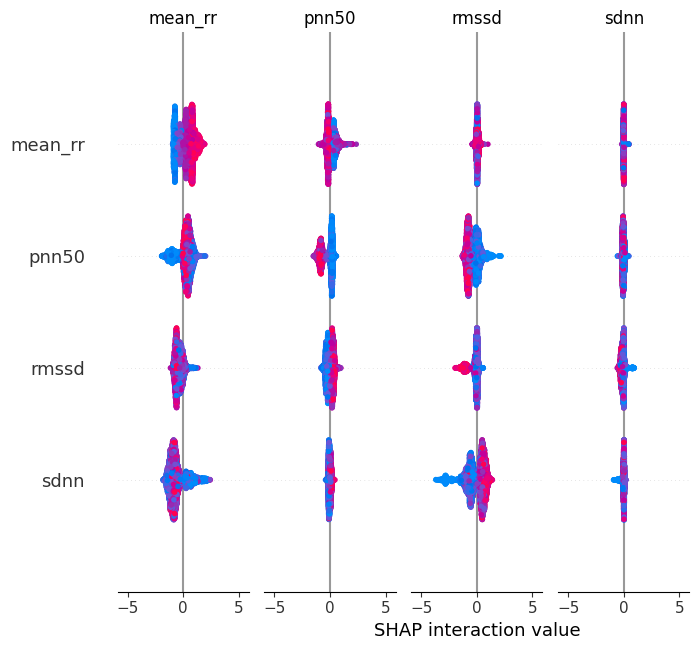

Saved shap_summary.png


In [13]:
import shap
sc_shap=StandardScaler(); X_cos_s=sc_shap.fit_transform(X_cos)
xgb_shap=make_xgb(); xgb_shap.fit(X_cos_s, y_cos,
    sample_weight=compute_sample_weight('balanced',y_cos), verbose=False)
explainer=shap.TreeExplainer(xgb_shap)
shap_values=explainer.shap_values(X_cos_s)

if isinstance(shap_values, list):
    imp=np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    imp=np.abs(shap_values).mean(axis=0)
    if imp.ndim>1: imp=imp.mean(axis=1)
imp=np.asarray(imp).flatten()

order=np.argsort(imp)[::-1]
print("Top 12 features by mean |SHAP|:")
for r,idx in enumerate(order[:12]):
    tag=""
    if XGB_FEATURE_NAMES[idx] in RESIDUAL_NAMES+['mesor','amplitude']: tag=" <- Cosinor"
    elif XGB_FEATURE_NAMES[idx] in CIRC_NAMES: tag=" <- circadian"
    print(f"  {r+1:2d}. {XGB_FEATURE_NAMES[idx]:<12} {imp[idx]:.4f}{tag}")

plt.figure()
try:
    shap.summary_plot(shap_values, X_cos_s, feature_names=XGB_FEATURE_NAMES,
                      class_names=CLASS_NAMES, show=False)
    plt.tight_layout(); plt.savefig(f'{SAVE_PATH}/shap_summary.png',dpi=150,bbox_inches='tight')
    plt.show()
except Exception as e:
    print("summary_plot note:", e)
print("Saved shap_summary.png")

## 12. Experiment 5 - Confusion Matrix (Ensemble, WESAD LOSO)

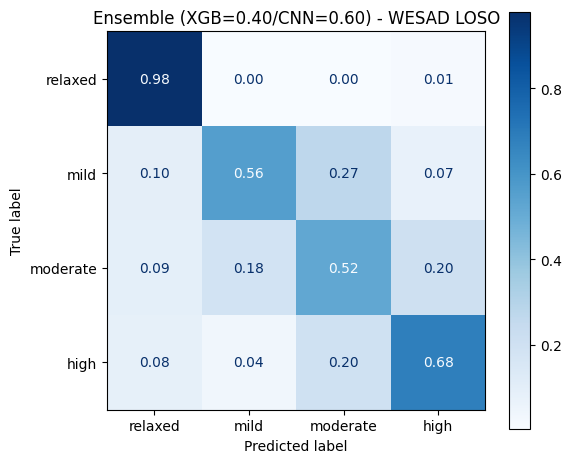

Saved ensemble_confusion.png


In [14]:
cm=confusion_matrix(yt_e,yp_e,normalize='true')
fig,ax=plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm,display_labels=CLASS_NAMES).plot(cmap='Blues',ax=ax,values_format='.2f')
ax.set_title(f'Ensemble (XGB={W_XGB:.2f}/CNN={W_CNN:.2f}) - WESAD LOSO')
plt.tight_layout(); plt.savefig(f'{SAVE_PATH}/ensemble_confusion.png',dpi=150); plt.show()
print("Saved ensemble_confusion.png")

## 13. Experiment 6 - Per-Class Summary & Full Comparison Table

In [15]:
rep=classification_report(yt_e,yp_e,target_names=CLASS_NAMES,output_dict=True,zero_division=0)
print("Ensemble per-class F1:")
for c in CLASS_NAMES: print(f"  {c:<10}: {rep[c]['f1-score']:.3f}")

print("\n"+"="*58); print("FULL COMPARISON - WESAD LOSO-CV"); print("="*58)
print(f"{'Model':<26}{'Acc':>7}{'F1':>7}{'Kappa':>8}"); print("-"*58)
print(f"{'XGBoost HRV only':<26}{res_hrv['acc']:>7.3f}{res_hrv['f1']:>7.3f}{res_hrv['kappa']:>8.3f}")
print(f"{'XGBoost + Cosinor':<26}{res_cos['acc']:>7.3f}{res_cos['f1']:>7.3f}{res_cos['kappa']:>8.3f}")
print(f"{'CNN-BiLSTM-Attn v2':<26}{res_cnn['acc']:>7.3f}{res_cnn['f1']:>7.3f}{res_cnn['kappa']:>8.3f}")
lbl='Ensemble '+str(round(W_XGB,2))+'/'+str(round(W_CNN,2))
print(f"{lbl:<26}{res_ens['acc']:>7.3f}{res_ens['f1']:>7.3f}{res_ens['kappa']:>8.3f}")
print("="*58)

Ensemble per-class F1:
  relaxed   : 0.973
  mild      : 0.622
  moderate  : 0.510
  high      : 0.658

FULL COMPARISON - WESAD LOSO-CV
Model                         Acc     F1   Kappa
----------------------------------------------------------
XGBoost HRV only            0.810  0.587   0.695
XGBoost + Cosinor           0.858  0.634   0.824
CNN-BiLSTM-Attn v2          0.856  0.657   0.820
Ensemble 0.4/0.6            0.871  0.691   0.833


## 14. Save Models, Results & Download Links

In [16]:
cnn_final.save(f'{MODELS_PATH}/cnn_bilstm_v2_final.keras')
pickle.dump(xgb_final, open(f'{MODELS_PATH}/xgb_cosinor_final.pkl','wb'))
pickle.dump(scaler_final, open(f'{MODELS_PATH}/xgb_scaler.pkl','wb'))
all_results={
    'XGBoost HRV only':res_hrv,'XGBoost + Cosinor':res_cos,
    'CNN-BiLSTM-Attn v2':res_cnn,
    'Ensemble':{**res_ens,'weights':{'xgb':W_XGB,'cnn':W_CNN},
                'per_class':{c:float(rep[c]['f1-score']) for c in CLASS_NAMES}}}
with open(f'{SAVE_PATH}/all_results.json','w') as f: json.dump(all_results,f,indent=2)
print(json.dumps(all_results,indent=2))

{
  "XGBoost HRV only": {
    "acc": 0.8103390957446809,
    "f1": 0.5874526283100772,
    "kappa": 0.6951725731822662
  },
  "XGBoost + Cosinor": {
    "acc": 0.8583776595744681,
    "f1": 0.6341391708073619,
    "kappa": 0.8239228940664789
  },
  "CNN-BiLSTM-Attn v2": {
    "acc": 0.855647475941246,
    "f1": 0.6571256256458164,
    "kappa": 0.8197882017909839
  },
  "Ensemble": {
    "acc": 0.871264561877427,
    "f1": 0.6908634392218647,
    "kappa": 0.8329311650293197,
    "weights": {
      "xgb": 0.4,
      "cnn": 0.6
    },
    "per_class": {
      "relaxed": 0.9727824328228836,
      "mild": 0.6224024328433857,
      "moderate": 0.5100182149362478,
      "high": 0.6582506762849414
    }
  }
}


In [17]:
from IPython.display import FileLink, display
print("DOWNLOAD THESE (so you never lose them):")
for fp in ['models/cnn_bilstm_v2_final.keras','models/xgb_cosinor_final.pkl',
           'models/xgb_scaler.pkl','all_results.json',
           'shap_summary.png','ensemble_confusion.png']:
    p=f'{SAVE_PATH}/{fp}'
    if os.path.exists(p): display(FileLink(p))

DOWNLOAD THESE (so you never lose them):


/kaggle/working/processed/models/cnn_bilstm_v2_final.keras

/kaggle/working/processed/models/xgb_cosinor_final.pkl

/kaggle/working/processed/models/xgb_scaler.pkl

/kaggle/working/processed/all_results.json

/kaggle/working/processed/shap_summary.png

/kaggle/working/processed/ensemble_confusion.png

## Done
Produced everything for the results chapter: XGBoost ablation, CNN v2, ensemble
with weight tuning, SHAP importance, confusion matrix, per-class F1, comparison table.

**Before closing:** click the download links, or Save Version -> Save & Run All.
Cross-dataset (Empatica) validation is in the separate merged pipeline notebook.


## 15. Circadian Validation — In-Situ Wearable HRV Dataset (Baigutanova et al., 2025)

WESAD sessions are ~1-2h, so a 24h Cosinor rhythm is not identifiable there (see the
diagnostic printed in Section 4). This section fits the **same Cosinor model** — using
the linear-regression formulation from Section 3.2.3 of the proposal
(Y(t) = M + b1*cos(wt) + b2*sin(wt), amplitude = sqrt(b1^2+b2^2), acrophase = atan2(-b2,b1)) —
on a dataset that actually spans enough of the 24h cycle: 49 subjects x ~4 weeks of
real-world smartwatch HRV with genuine wall-clock timestamps (CC BY 4.0, no access
restriction). https://doi.org/10.6084/m9.figshare.28509740

A zero-amplitude F-test (comparing the fitted cosine against an intercept-only null
model) is used instead of just reporting R^2, so 'is there a real 24h rhythm here'
is a statistical claim, not just a visual one.

In [18]:
# ================= In-Situ Wearable Dataset — load + quality filter =================
INSITU_CSV       = '/kaggle/input/datasets/pererabg/insitu-hrv-sleep/sensor_hrv_filtered.csv'  # <-- set to your actual path
MISSINGNESS_MAX  = 0.35   # dataset's own recommended threshold (safeguard; file is pre-filtered)
MIN_POINTS       = 200    # minimum clean 5-min samples per subject/metric to attempt a fit
TZ_OFFSET_HOURS  = 9.0    # KST (UTC+9) -- confirm from the dataset README; set 0.0 to keep UTC

df_insitu = pd.read_csv(INSITU_CSV)
print(f"Loaded {len(df_insitu):,} rows, {df_insitu['deviceId'].nunique()} devices")

def to_local_hours(ts_epoch):
    # ts_start/ts_end can be epoch seconds or ms depending on export; auto-detect.
    ts = ts_epoch.astype(float)
    ts_sec = np.where(ts > 1e11, ts/1000.0, ts)
    return ts_sec/3600.0 + TZ_OFFSET_HOURS   # continuous local hours (NOT wrapped -- keeps the fit valid)

df_insitu['t_hours']    = to_local_hours(df_insitu['ts_start'].values)
df_insitu['clock_hour'] = df_insitu['t_hours'] % 24.0
df_insitu = df_insitu[df_insitu['missingness_score'] <= MISSINGNESS_MAX].copy()
print(f"After quality filter (<= {MISSINGNESS_MAX} missingness): {len(df_insitu):,} rows")
print(df_insitu[['deviceId','ts_start','t_hours','clock_hour','rmssd','sdnn']].head())

Loaded 38,913 rows, 49 devices
After quality filter (<= 0.35 missingness): 38,913 rows
  deviceId       ts_start        t_hours  clock_hour       rmssd        sdnn
0     ab60  1617262425031  449248.562509   16.562509   98.417649   89.363225
1     ab60  1616736817151  449102.560320   14.560320  106.602933  100.804974
2     ab60  1616736517083  449102.476967   14.476967   74.504896   89.073518
3     ab60  1616736217077  449102.393632   14.393632   70.615187  102.371770
4     ab60  1616734416800  449101.893556   13.893556   66.973170   84.045665


In [19]:
# ================= Per-subject Cosinor fit (linear form, matches proposal 3.2.3) + zero-amplitude test =================
from scipy import stats as sstats

def fit_cosinor_linear(t_hours, y, period=24.0):
    """Single-component Cosinor via linear regression:
       Y(t) = M + b1*cos(wt) + b2*sin(wt) + eps ,  w = 2*pi/period
    Returns MESOR, amplitude, acrophase (proposal Eq. 3.2.3) plus a zero-amplitude F-test:
       H0: b1 = b2 = 0  (no 24h rhythm)  vs  H1: full cosinor model.
    """
    w = 2*np.pi/period
    X = np.column_stack([np.ones_like(t_hours), np.cos(w*t_hours), np.sin(w*t_hours)])
    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    M, b1, b2 = beta
    baseline = X @ beta
    resid = y - baseline
    rss_full = np.sum(resid**2)
    rss_null = np.sum((y - np.mean(y))**2)
    n = len(y); ddf1, ddf2 = 2, n-3
    F = ((rss_null - rss_full)/ddf1) / (rss_full/ddf2) if ddf2 > 0 and rss_full > 0 else np.nan
    p_val = sstats.f.sf(F, ddf1, ddf2) if np.isfinite(F) else np.nan
    amplitude = np.sqrt(b1**2 + b2**2)
    acrophase = np.arctan2(-b2, b1)
    r2 = 1 - rss_full/rss_null if rss_null > 0 else np.nan
    return dict(mesor=M, amplitude=amplitude, acrophase=acrophase, r2=r2,
                F=F, p_value=p_val, baseline=baseline, residual=resid, n=n)

insitu_results = []
for dev, g in df_insitu.groupby('deviceId'):
    g = g.sort_values('t_hours')
    span_h = g['t_hours'].max() - g['t_hours'].min()
    for metric in ['rmssd', 'sdnn']:
        y = g[metric].values.astype(float); t = g['t_hours'].values.astype(float)
        mask = np.isfinite(y) & np.isfinite(t)
        if mask.sum() < MIN_POINTS:
            continue
        fit = fit_cosinor_linear(t[mask], y[mask])
        fit.update(deviceId=dev, metric=metric, span_hours=span_h,
                    span_days=span_h/24.0, n_points=int(mask.sum()))
        insitu_results.append(fit)

res_insitu = pd.DataFrame(insitu_results)
res_insitu['significant_24h_rhythm'] = res_insitu['p_value'] < 0.05

print(res_insitu[['deviceId','metric','n_points','span_days','mesor','amplitude',
                   'r2','F','p_value','significant_24h_rhythm']].round(4).to_string(index=False))

pct_sig = res_insitu['significant_24h_rhythm'].mean()*100
print(f"\n{pct_sig:.1f}% of subject-metric fits show a statistically significant (p<0.05) 24h rhythm.")
for m in ['rmssd','sdnn']:
    sub = res_insitu[res_insitu.metric==m]
    print(f"  {m.upper()}: median R2={sub['r2'].median():.3f}, median amplitude={sub['amplitude'].median():.2f}")

res_insitu.to_csv(f'{SAVE_PATH}/insitu_cosinor_fits.csv', index=False)
print(f"\nSaved per-subject fit table -> {SAVE_PATH}/insitu_cosinor_fits.csv")

deviceId metric  n_points  span_days    mesor  amplitude     r2        F  p_value  significant_24h_rhythm
    ab60  rmssd      1103    31.3540  75.3880     3.2986 0.0028   1.5409   0.2147                   False
    ab60   sdnn      1103    31.3540  77.9858     3.5347 0.0169   9.4761   0.0001                    True
    am77  rmssd       285    30.2232  74.3790     5.4201 0.0175   2.5045   0.0835                   False
    am77   sdnn       285    30.2232  79.3246     1.7182 0.0033   0.4717   0.6244                   False
    av54  rmssd       415    26.5460  70.8382     8.2904 0.0452   9.7438   0.0001                    True
    av54   sdnn       415    26.5460  69.4406     6.2389 0.0483  10.4532   0.0000                    True
    ba30  rmssd      1045    34.9651  87.0821    15.1536 0.0755  42.5305   0.0000                    True
    ba30   sdnn      1045    34.9651  88.1634    15.4049 0.0918  52.6367   0.0000                    True
    bp16  rmssd       528    27.4154  76.0121 

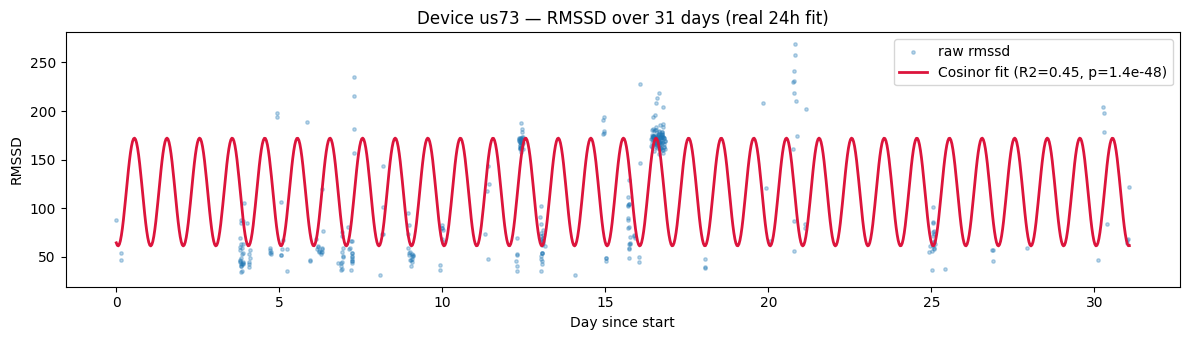


Example residual stats (device us73, rmssd): mean=-0.000, std=44.646


In [20]:
# ---- visual check: best-fitting subject, raw signal vs fitted 24h Cosinor curve ----
best = res_insitu.sort_values('r2', ascending=False).iloc[0]
g = df_insitu[df_insitu.deviceId == best.deviceId].sort_values('t_hours')
y = g[best.metric].values.astype(float); t = g['t_hours'].values.astype(float)
fit = fit_cosinor_linear(t, y)
w = 2*np.pi/24.0
tt = np.linspace(t.min(), t.max(), 1000)
baseline_curve = fit['mesor'] + fit['amplitude']*np.cos(w*tt + fit['acrophase'])

plt.figure(figsize=(12,3.5))
plt.scatter((t-t.min())/24.0, y, s=6, alpha=0.3, label=f'raw {best.metric}')
plt.plot((tt-t.min())/24.0, baseline_curve, color='crimson', lw=2,
         label=f"Cosinor fit (R2={fit['r2']:.2f}, p={fit['p_value']:.1e})")
plt.xlabel('Day since start'); plt.ylabel(best.metric.upper())
plt.title(f"Device {best.deviceId} — {best.metric.upper()} over {best.span_days:.0f} days (real 24h fit)")
plt.legend(); plt.tight_layout(); plt.savefig(f'{SAVE_PATH}/insitu_cosinor_example.png', dpi=120); plt.show()

# residual = detrended signal, the same quantity used as 'Cosinor residual' feature
# in Section 3.2.4 -- this is the version that is actually validated (unlike WESAD).
print(f"\nExample residual stats (device {best.deviceId}, {best.metric}): "
      f"mean={fit['residual'].mean():.3f}, std={fit['residual'].std():.3f}")

**How to report this in the dissertation:** state the % of subject-metric fits with
p<0.05 (real, statistically tested 24h rhythm — not just a plausible-looking curve),
the median R^2, and show the example plot. Contrast this explicitly with the WESAD
diagnostic table from Section 3/4 (every subject <2h span, rhythm not identifiable).
That contrast *is* the evidence that your Cosinor detrending mechanism is real and
was properly validated, before it's reused as a feature for stress classification.

In [21]:
# ================= In-Situ Wearable Dataset — load + quality filter =================
INSITU_CSV       = '/kaggle/input/datasets/pererabg/insitu-hrv-sleep/sensor_hrv_filtered.csv'  # <-- set to your actual path
MISSINGNESS_MAX  = 0.35   # dataset's own recommended threshold (safeguard; file is pre-filtered)
MIN_POINTS       = 200    # minimum clean 5-min samples per subject/metric to attempt a fit
TZ_OFFSET_HOURS  = 9.0    # KST (UTC+9) -- confirm from the dataset README; set 0.0 to keep UTC

df_insitu = pd.read_csv(INSITU_CSV)
print(f"Loaded {len(df_insitu):,} rows, {df_insitu['deviceId'].nunique()} devices")

def to_local_hours(ts_epoch):
    # ts_start/ts_end can be epoch seconds or ms depending on export; auto-detect.
    ts = ts_epoch.astype(float)
    ts_sec = np.where(ts > 1e11, ts/1000.0, ts)
    return ts_sec/3600.0 + TZ_OFFSET_HOURS   # continuous local hours (NOT wrapped -- keeps the fit valid)

df_insitu['t_hours']    = to_local_hours(df_insitu['ts_start'].values)
df_insitu['clock_hour'] = df_insitu['t_hours'] % 24.0
df_insitu = df_insitu[df_insitu['missingness_score'] <= MISSINGNESS_MAX].copy()

# ---- guard against corrupt timestamps (e.g. subject sm34 showed span=1186 days) ----
# The study is ~4 weeks; drop rows whose time is >35 days from that subject's median.
df_insitu['t_days'] = df_insitu['t_hours']/24.0
_med = df_insitu.groupby('deviceId')['t_days'].transform('median')
_before = len(df_insitu)
df_insitu = df_insitu[(df_insitu['t_days'] - _med).abs() <= 35].copy()
print(f"Timestamp guard removed {_before - len(df_insitu)} corrupt-timestamp rows")
print(f"After quality filter (<= {MISSINGNESS_MAX} missingness): {len(df_insitu):,} rows")
print(df_insitu[['deviceId','ts_start','t_hours','clock_hour','rmssd','sdnn']].head())

Loaded 38,913 rows, 49 devices
Timestamp guard removed 1 corrupt-timestamp rows
After quality filter (<= 0.35 missingness): 38,912 rows
  deviceId       ts_start        t_hours  clock_hour       rmssd        sdnn
0     ab60  1617262425031  449248.562509   16.562509   98.417649   89.363225
1     ab60  1616736817151  449102.560320   14.560320  106.602933  100.804974
2     ab60  1616736517083  449102.476967   14.476967   74.504896   89.073518
3     ab60  1616736217077  449102.393632   14.393632   70.615187  102.371770
4     ab60  1616734416800  449101.893556   13.893556   66.973170   84.045665


In [22]:
# ================= Per-subject Cosinor fit (linear form, matches proposal 3.2.3) + zero-amplitude test =================
from scipy import stats as sstats

def fit_cosinor_linear(t_hours, y, period=24.0):
    """Single-component Cosinor via linear regression:
       Y(t) = M + b1*cos(wt) + b2*sin(wt) + eps ,  w = 2*pi/period
    Returns MESOR, amplitude, acrophase (proposal Eq. 3.2.3) plus a zero-amplitude F-test:
       H0: b1 = b2 = 0  (no 24h rhythm)  vs  H1: full cosinor model.
    """
    w = 2*np.pi/period
    X = np.column_stack([np.ones_like(t_hours), np.cos(w*t_hours), np.sin(w*t_hours)])
    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    M, b1, b2 = beta
    baseline = X @ beta
    resid = y - baseline
    rss_full = np.sum(resid**2)
    rss_null = np.sum((y - np.mean(y))**2)
    n = len(y); ddf1, ddf2 = 2, n-3
    F = ((rss_null - rss_full)/ddf1) / (rss_full/ddf2) if ddf2 > 0 and rss_full > 0 else np.nan
    p_val = sstats.f.sf(F, ddf1, ddf2) if np.isfinite(F) else np.nan
    amplitude = np.sqrt(b1**2 + b2**2)
    acrophase = np.arctan2(-b2, b1)
    r2 = 1 - rss_full/rss_null if rss_null > 0 else np.nan
    return dict(mesor=M, amplitude=amplitude, acrophase=acrophase, r2=r2,
                F=F, p_value=p_val, baseline=baseline, residual=resid, n=n)

insitu_results = []
for dev, g in df_insitu.groupby('deviceId'):
    g = g.sort_values('t_hours')
    span_h = g['t_hours'].max() - g['t_hours'].min()
    for metric in ['rmssd', 'sdnn']:
        y = g[metric].values.astype(float); t = g['t_hours'].values.astype(float)
        mask = np.isfinite(y) & np.isfinite(t)
        if mask.sum() < MIN_POINTS:
            continue
        fit = fit_cosinor_linear(t[mask], y[mask])
        fit.update(deviceId=dev, metric=metric, span_hours=span_h,
                    span_days=span_h/24.0, n_points=int(mask.sum()))
        insitu_results.append(fit)

res_insitu = pd.DataFrame(insitu_results)
res_insitu['significant_24h_rhythm'] = res_insitu['p_value'] < 0.05

print(res_insitu[['deviceId','metric','n_points','span_days','mesor','amplitude',
                   'r2','F','p_value','significant_24h_rhythm']].round(4).to_string(index=False))

pct_sig = res_insitu['significant_24h_rhythm'].mean()*100
print(f"\n{pct_sig:.1f}% of subject-metric fits show a statistically significant (p<0.05) 24h rhythm.")
for m in ['rmssd','sdnn']:
    sub = res_insitu[res_insitu.metric==m]
    print(f"  {m.upper()}: median R2={sub['r2'].median():.3f}, median amplitude={sub['amplitude'].median():.2f}")

res_insitu.to_csv(f'{SAVE_PATH}/insitu_cosinor_fits.csv', index=False)
print(f"\nSaved per-subject fit table -> {SAVE_PATH}/insitu_cosinor_fits.csv")

deviceId metric  n_points  span_days    mesor  amplitude     r2        F  p_value  significant_24h_rhythm
    ab60  rmssd      1103    31.3540  75.3880     3.2986 0.0028   1.5409   0.2147                   False
    ab60   sdnn      1103    31.3540  77.9858     3.5347 0.0169   9.4761   0.0001                    True
    am77  rmssd       285    30.2232  74.3790     5.4201 0.0175   2.5045   0.0835                   False
    am77   sdnn       285    30.2232  79.3246     1.7182 0.0033   0.4717   0.6244                   False
    av54  rmssd       415    26.5460  70.8382     8.2904 0.0452   9.7438   0.0001                    True
    av54   sdnn       415    26.5460  69.4406     6.2389 0.0483  10.4532   0.0000                    True
    ba30  rmssd      1045    34.9651  87.0821    15.1536 0.0755  42.5305   0.0000                    True
    ba30   sdnn      1045    34.9651  88.1634    15.4049 0.0918  52.6367   0.0000                    True
    bp16  rmssd       528    27.4154  76.0121 

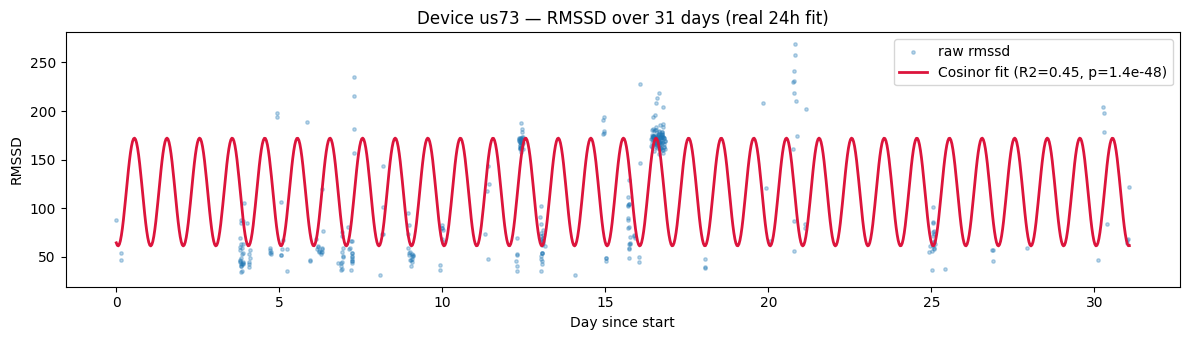


Example residual stats (device us73, rmssd): mean=-0.000, std=44.646


In [23]:
# ---- visual check: best-fitting subject, raw signal vs fitted 24h Cosinor curve ----
best = res_insitu.sort_values('r2', ascending=False).iloc[0]
g = df_insitu[df_insitu.deviceId == best.deviceId].sort_values('t_hours')
y = g[best.metric].values.astype(float); t = g['t_hours'].values.astype(float)
fit = fit_cosinor_linear(t, y)
w = 2*np.pi/24.0
tt = np.linspace(t.min(), t.max(), 1000)
baseline_curve = fit['mesor'] + fit['amplitude']*np.cos(w*tt + fit['acrophase'])

plt.figure(figsize=(12,3.5))
plt.scatter((t-t.min())/24.0, y, s=6, alpha=0.3, label=f'raw {best.metric}')
plt.plot((tt-t.min())/24.0, baseline_curve, color='crimson', lw=2,
         label=f"Cosinor fit (R2={fit['r2']:.2f}, p={fit['p_value']:.1e})")
plt.xlabel('Day since start'); plt.ylabel(best.metric.upper())
plt.title(f"Device {best.deviceId} — {best.metric.upper()} over {best.span_days:.0f} days (real 24h fit)")
plt.legend(); plt.tight_layout(); plt.savefig(f'{SAVE_PATH}/insitu_cosinor_example.png', dpi=120); plt.show()

# residual = detrended signal, the same quantity used as 'Cosinor residual' feature
# in Section 3.2.4 -- this is the version that is actually validated (unlike WESAD).
print(f"\nExample residual stats (device {best.deviceId}, {best.metric}): "
      f"mean={fit['residual'].mean():.3f}, std={fit['residual'].std():.3f}")

## 16. Experiment 7 — Label-Circularity Ablation (RMSSD-derived features)

The four stress levels for the *stress* condition were defined by binning a local RMSSD
statistic into terciles (mild/moderate/high). RMSSD, and the Poincaré features derived
from the same successive-difference information (sd1, sd2, sd_ratio), are also model
inputs. This risks **circularity**: the classifier could be re-learning the thresholded
version of its own input rather than detecting genuine stress severity.

This experiment removes the RMSSD-family features (`rmssd, sd1, sd2, sd_ratio`) and re-runs
the same XGBoost LOSO pipeline, reporting **per-class F1**. Interpretation:
- If `mild/moderate/high` F1 **collapse toward chance** when these features are removed →
  the multi-level result was substantially driven by label circularity.
- If they **largely hold up** → the levels carry information beyond the defining statistic,
  and the multi-level claim is more defensible.

A per-class SHAP breakdown is also produced to see whether `rmssd`/`sd1` dominate the
`mild/moderate/high` predictions specifically.

In [24]:
# ================= Experiment 7: label-circularity ablation =================
from sklearn.metrics import f1_score as _f1

# Feature layout of X_cos (from build_cosinor_matrix), in order:
#   FEATURE_NAMES(13) + RESIDUAL_NAMES(5) + ['mesor','amplitude'](2) + CIRC_NAMES(5)
ABLATION_FULL_NAMES = FEATURE_NAMES + RESIDUAL_NAMES + ['mesor','amplitude'] + CIRC_NAMES
assert X_cos.shape[1] == len(ABLATION_FULL_NAMES), (X_cos.shape[1], len(ABLATION_FULL_NAMES))

# The features that DEFINE the labels (RMSSD + Poincaré derived from successive diffs)
LEAK_FEATURES = ['rmssd','sd1','sd2','sd_ratio']
leak_idx = [ABLATION_FULL_NAMES.index(f) for f in LEAK_FEATURES]
keep_idx = [i for i in range(len(ABLATION_FULL_NAMES)) if i not in leak_idx]
print("Removing RMSSD-family features:", LEAK_FEATURES, "-> indices", leak_idx)
print(f"Features: {len(ABLATION_FULL_NAMES)} full -> {len(keep_idx)} after ablation\n")

def run_xgb_loso_perclass(X, y, groups, label=""):
    logo = LeaveOneGroupOut(); yt, yp = [], []
    for tr, te in logo.split(X, y, groups):
        sc = StandardScaler(); Xtr = sc.fit_transform(X[tr]); Xte = sc.transform(X[te])
        sw = compute_sample_weight('balanced', y[tr])
        m = make_xgb(); m.fit(Xtr, y[tr], sample_weight=sw, verbose=False)
        yt.extend(y[te]); yp.extend(m.predict(Xte))
    yt, yp = np.array(yt), np.array(yp)
    per_class = _f1(yt, yp, average=None, labels=[0,1,2,3], zero_division=0)
    macro = _f1(yt, yp, average='macro', zero_division=0)
    print(f"{label}")
    print(f"  macro F1 = {macro:.3f}")
    for ci, cname in enumerate(CLASS_NAMES):
        print(f"    {cname:9s} F1 = {per_class[ci]:.3f}")
    return macro, per_class

print("="*55)
macro_full, pc_full = run_xgb_loso_perclass(X_cos, y_cos, groups_cos,
                                            "FULL (with RMSSD-family)")
print("="*55)
macro_abl, pc_abl = run_xgb_loso_perclass(X_cos[:, keep_idx], y_cos, groups_cos,
                                          "ABLATED (RMSSD-family removed)")
print("="*55)

print("\nPer-class F1 change (ablated - full):")
print(f"{'class':10s} {'full':>7} {'ablated':>8} {'delta':>7}")
for ci, cname in enumerate(CLASS_NAMES):
    d = pc_abl[ci] - pc_full[ci]
    flag = "  <-- large drop" if d < -0.15 else ""
    print(f"{cname:10s} {pc_full[ci]:7.3f} {pc_abl[ci]:8.3f} {d:+7.3f}{flag}")
print(f"{'macro':10s} {macro_full:7.3f} {macro_abl:8.3f} {macro_abl-macro_full:+7.3f}")

print("""
INTERPRETATION GUIDE:
  - relaxed should barely move (it is a REAL WESAD label, not RMSSD-defined).
  - If mild/moderate/high drop sharply (delta < -0.15), the multi-level separation
    was substantially label-circular. Report honestly + consider EDA-derived severity.
  - If they hold within ~0.10, the levels carry signal beyond the defining statistic.""")

Removing RMSSD-family features: ['rmssd', 'sd1', 'sd2', 'sd_ratio'] -> indices [2, 10, 11, 12]
Features: 25 full -> 21 after ablation

FULL (with RMSSD-family)
  macro F1 = 0.634
    relaxed   F1 = 0.976
    mild      F1 = 0.575
    moderate  F1 = 0.379
    high      F1 = 0.607
ABLATED (RMSSD-family removed)
  macro F1 = 0.625
    relaxed   F1 = 0.975
    mild      F1 = 0.561
    moderate  F1 = 0.359
    high      F1 = 0.605

Per-class F1 change (ablated - full):
class         full  ablated   delta
relaxed      0.976    0.975  -0.001
mild         0.575    0.561  -0.013
moderate     0.379    0.359  -0.021
high         0.607    0.605  -0.002
macro        0.634    0.625  -0.009

INTERPRETATION GUIDE:
  - relaxed should barely move (it is a REAL WESAD label, not RMSSD-defined).
  - If mild/moderate/high drop sharply (delta < -0.15), the multi-level separation
    was substantially label-circular. Report honestly + consider EDA-derived severity.
  - If they hold within ~0.10, the levels car

In [25]:
# ---- per-class SHAP: do rmssd/sd1 dominate mild/moderate/high specifically? ----
import shap
sc_ab = StandardScaler(); X_cos_sc = sc_ab.fit_transform(X_cos)
m_ab = make_xgb()
m_ab.fit(X_cos_sc, y_cos, sample_weight=compute_sample_weight('balanced', y_cos), verbose=False)

expl = shap.TreeExplainer(m_ab)
sv = expl.shap_values(X_cos_sc)   # list of 4 arrays (one per class) for multiclass

def top_feats_for_class(class_idx, k=8):
    vals = np.abs(sv[class_idx]).mean(axis=0)
    order = np.argsort(vals)[::-1][:k]
    return [(ABLATION_FULL_NAMES[i], vals[i]) for i in order]

print("Top-8 SHAP features per class (mean |SHAP|):\n")
for ci, cname in enumerate(CLASS_NAMES):
    print(f"[{cname}]")
    for fname, val in top_feats_for_class(ci):
        mark = "  *** LABEL-DEFINING" if fname in LEAK_FEATURES else ""
        print(f"    {fname:12s} {val:.4f}{mark}")
    print()
print("If rmssd/sd1/sd2/sd_ratio sit at the TOP for mild/moderate/high, that is the\n"
      "circularity showing directly. For 'relaxed' they may legitimately matter.")

Top-8 SHAP features per class (mean |SHAP|):

[relaxed]
    mean_rr      0.3652
    pnn50        0.2391
    sdnn         0.2079
    rmssd        0.1778  *** LABEL-DEFINING

[mild]
    mean_rr      0.3661
    pnn50        0.2422
    sdnn         0.2099
    rmssd        0.1735  *** LABEL-DEFINING

[moderate]
    mean_rr      0.3578
    pnn50        0.2206
    sdnn         0.2200
    rmssd        0.1903  *** LABEL-DEFINING

[high]
    mean_rr      0.3315
    pnn50        0.2277
    sdnn         0.2115
    rmssd        0.1813  *** LABEL-DEFINING

If rmssd/sd1/sd2/sd_ratio sit at the TOP for mild/moderate/high, that is the
circularity showing directly. For 'relaxed' they may legitimately matter.


## 17. Experiment 8 — CNN-BiLSTM Circularity Controls (main model)

The XGBoost ablation (Sec 16) probes feature-level circularity. The **CNN-BiLSTM-Attention**
is the *main* model, so it needs its own circularity evidence. Two complementary controls:

**(A) Channel-drop.** The CNN's input sequence has 7 channels:
`[rr_norm, rmssd_ch, sdnn_ch, hr_ch, rr_res_n, temp_norm, temp_res_n]`.
Channel 1 (`rmssd_ch`) is a rolling RMSSD — the exact quantity the mild/moderate/high
labels were cut from. We zero it out and retrain; if mild/moderate/high F1 collapses,
the model was leaning on the label-defining channel.

**(B) Permutation control (label shuffle within stress).** We randomly permute the
mild/moderate/high labels *among the stress-condition windows only* (relaxed untouched),
retrain, and measure. Under a true null (levels are separable only because RMSSD defines
them and RMSSD is in the input), the model can still partly recover shuffled labels from
the raw RR channels — that recovery quantifies how much 'separation' is circular rather
than stress-meaningful. Compared against the real-label score, this bounds the genuine
signal.

Both use a single stratified subject-held-out split (not full LOSO) to keep runtime
manageable — this is a diagnostic, not the headline metric.

In [26]:
# ================= Experiment 8: CNN-BiLSTM circularity controls =================
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score as _f1

RMSSD_CHANNEL = 1   # index of rmssd_ch in the 7-channel stack (see build_windows_v2)
CH_NAMES = ['rr_norm','rmssd_ch','sdnn_ch','hr_ch','rr_res_n','temp_norm','temp_res_n']
STRESS_CLASSES = [1,2,3]   # mild, moderate, high  (relaxed=0 untouched)

# one grouped train/test split (hold out ~20% of SUBJECTS)
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
tr_idx, te_idx = next(gss.split(X_seq, y_seq, groups_seq))
print(f"Train windows {len(tr_idx)}, Test windows {len(te_idx)}, "
      f"held-out subjects {np.unique(groups_seq[te_idx])}")

def train_eval_cnn(Xseq_tr, Xcirc_tr, y_tr, Xseq_te, Xcirc_te, y_te, tag):
    cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    cwd = dict(enumerate(cw))
    cnn = build_cnn()
    cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                loss=SparseFocalLoss(2.0), metrics=['accuracy'])
    cb = [callbacks.EarlyStopping(monitor='val_loss', patience=12,
                                   restore_best_weights=True, verbose=0),
          callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, verbose=0)]
    cnn.fit([Xseq_tr, Xcirc_tr], y_tr, validation_split=0.15, epochs=100,
            batch_size=32, class_weight=cwd, callbacks=cb, verbose=0)
    yp = np.argmax(cnn.predict([Xseq_te, Xcirc_te], verbose=0), axis=1)
    per = _f1(y_te, yp, average=None, labels=[0,1,2,3], zero_division=0)
    macro = _f1(y_te, yp, average='macro', zero_division=0)
    print(f"  [{tag}] macro F1={macro:.3f} | " +
          " ".join(f"{c}={per[i]:.3f}" for i,c in enumerate(CLASS_NAMES)))
    return macro, per

print("\n--- Baseline: real labels, all 7 channels ---")
m_base, pc_base = train_eval_cnn(
    X_seq[tr_idx], X_circ[tr_idx], y_seq[tr_idx],
    X_seq[te_idx], X_circ[te_idx], y_seq[te_idx], "REAL / full")

print("\n--- Control A: real labels, rmssd_ch zeroed ---")
Xseq_tr_z = X_seq[tr_idx].copy(); Xseq_tr_z[:,:,RMSSD_CHANNEL] = 0.0
Xseq_te_z = X_seq[te_idx].copy(); Xseq_te_z[:,:,RMSSD_CHANNEL] = 0.0
m_drop, pc_drop = train_eval_cnn(
    Xseq_tr_z, X_circ[tr_idx], y_seq[tr_idx],
    Xseq_te_z, X_circ[te_idx], y_seq[te_idx], "REAL / no-rmssd-ch")

print("\n--- Control B: shuffled mild/moderate/high labels (within stress) ---")
rng = np.random.default_rng(42)
y_shuf = y_seq.copy()
stress_mask = np.isin(y_seq, STRESS_CLASSES)
stress_pos = np.where(stress_mask)[0]
perm = rng.permutation(y_seq[stress_pos])   # shuffle only among stress windows
y_shuf[stress_pos] = perm
m_shuf, pc_shuf = train_eval_cnn(
    X_seq[tr_idx], X_circ[tr_idx], y_shuf[tr_idx],
    X_seq[te_idx], X_circ[te_idx], y_shuf[te_idx], "SHUFFLED-stress / full")

print("\n" + "="*60)
print("SUMMARY (per-class F1)")
print(f"{'class':10s} {'real':>7} {'no_rmssd':>9} {'shuffled':>9}")
for i,c in enumerate(CLASS_NAMES):
    print(f"{c:10s} {pc_base[i]:7.3f} {pc_drop[i]:9.3f} {pc_shuf[i]:9.3f}")
print(f"{'macro':10s} {m_base:7.3f} {m_drop:9.3f} {m_shuf:9.3f}")
print("="*60)
print("""
INTERPRETATION:
  real vs no_rmssd : how much the model leans on the label-defining channel.
     small drop  -> not just reading rmssd_ch (good).
     large drop  -> mild/mod/high separation depends on the defining channel.
  real vs shuffled: genuine signal above the circular baseline.
     real >> shuffled -> the levels carry real, non-circular structure (good).
     real ~ shuffled  -> separation is mostly circular; revisit labeling (e.g. EDA-based).
  relaxed(0) should stay high in real/no_rmssd and is unaffected by the stress shuffle.""")

Train windows 8450, Test windows 3396, held-out subjects [ 2 11 14 16]

--- Baseline: real labels, all 7 channels ---
  [REAL / full] macro F1=0.418 | relaxed=0.932 mild=0.055 moderate=0.146 high=0.540

--- Control A: real labels, rmssd_ch zeroed ---
  [REAL / no-rmssd-ch] macro F1=0.405 | relaxed=0.954 mild=0.072 moderate=0.114 high=0.479

--- Control B: shuffled mild/moderate/high labels (within stress) ---
  [SHUFFLED-stress / full] macro F1=0.423 | relaxed=0.952 mild=0.334 moderate=0.000 high=0.407

SUMMARY (per-class F1)
class         real  no_rmssd  shuffled
relaxed      0.932     0.954     0.952
mild         0.055     0.072     0.334
moderate     0.146     0.114     0.000
high         0.540     0.479     0.407
macro        0.418     0.405     0.423

INTERPRETATION:
  real vs no_rmssd : how much the model leans on the label-defining channel.
     small drop  -> not just reading rmssd_ch (good).
     large drop  -> mild/mod/high separation depends on the defining channel.
  real v